In [1]:
import numpy as np
import struct

def tensor_to_vol(tensor, filename, bbox=(0,0,0,1,1,1)):
    '''
    tensor: a 3D numpy array of shape (Z, Y, X)
    filename: output filename
    bbox: tuple of bounding box values (xmin, ymin, zmin, xmax, ymax, zmax)
    '''

    # Validate tensor dimensionality
    if len(tensor.shape) not in [3, 4]:
        raise ValueError("Tensor should be 3D or 4D.")
    
    z, y, x = tensor.shape[0], tensor.shape[1], tensor.shape[2]
    channels = 1 if len(tensor.shape) == 3 else tensor.shape[3]

    # Validate channel information
    if channels not in [1, 3, 6]:
        raise ValueError("Number of channels must be 1, 3, or 6.")

    # Create the header
    header = b'VOL'  # first 3 bytes
    header += struct.pack('B', 3)  # version number byte
    header += struct.pack('I', 1)  # encoding identifier (32-bit integer)
    header += struct.pack('I', x)  # Number of cells along the X axis
    header += struct.pack('I', y)  # Number of cells along the Y axis
    header += struct.pack('I', z)  # Number of cells along the Z axis
    header += struct.pack('I', channels)  # Number of channels

    # Add bounding box information
    for value in bbox:
        header += struct.pack('f', value)  # bounding box in single precision

    # Convert tensor to binary data in float32 format
    data = tensor.astype(np.float32).tobytes()

    with open(filename, 'wb') as f:
        f.write(header)
        f.write(data)

# Example usage
tensor = np.random.rand(10, 10, 10)
tensor_to_vol(tensor, 'output.vol', bbox=(0, 0, 0, 10, 10, 10))

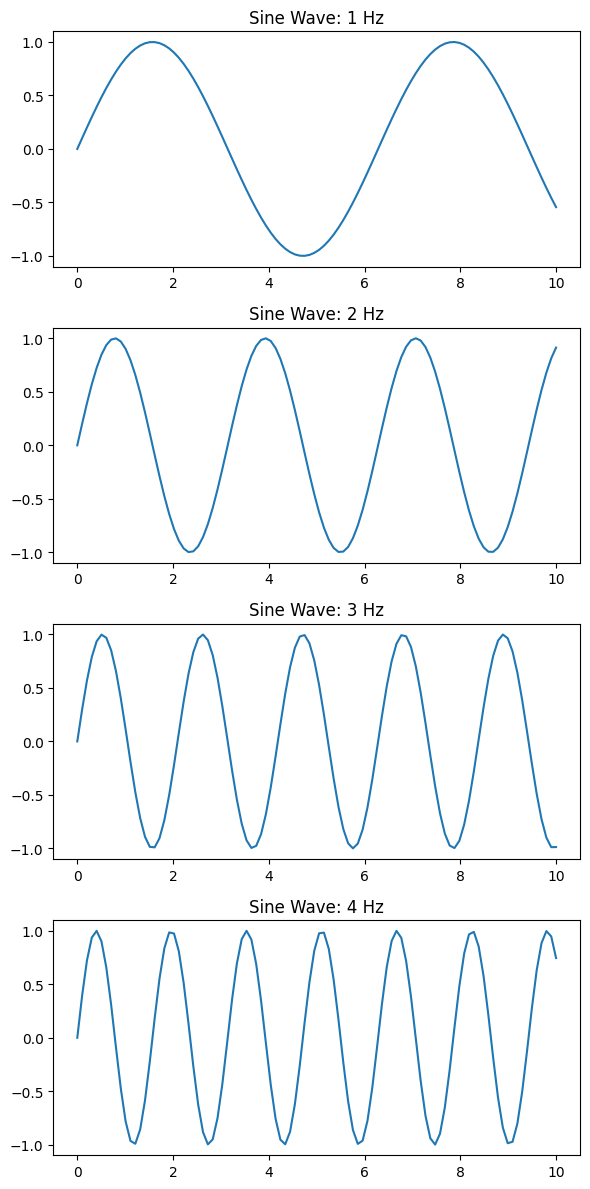

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data generation
x = np.linspace(0, 10, 100)

# Function to generate a sine wave plot for a given frequency
def plot_sine_wave(ax, frequency):
    y = np.sin(frequency * x)
    ax.plot(x, y)
    ax.set_title(f'Sine Wave: {frequency} Hz')

# Frequencies for which we want to generate subplots
frequencies = [1, 2, 3, 4]

# Number of subplots
n = len(frequencies)

# Create the subplots
fig, axarr = plt.subplots(n, 1, figsize=(6, 3 * n))

# Generate a subplot for each frequency
for i, freq in enumerate(frequencies):
    plot_sine_wave(axarr[i], freq)
    

plt.tight_layout()
plt.show()

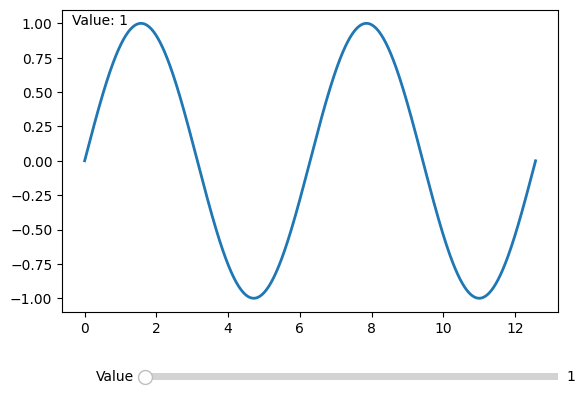

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# Initial data
val0 = 1
t = np.linspace(0.0, 4.0*np.pi, 1000)
s = np.sin(val0 * t)

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)
line, = ax.plot(t, s, lw=2)

# Text to display the value
val_text = ax.text(0.02, 0.95, f'Value: {val0}', transform=ax.transAxes)

axcolor = 'lightgoldenrodyellow'
axval = plt.axes([0.25, 0.1, 0.65, 0.03], facecolor=axcolor)

sval = Slider(axval, 'Value', 0, 128, valinit=val0, valfmt='%0.0f')

def update(val):
    current_val = int(sval.val)  # Convert the slider value to an integer
    line.set_ydata(np.sin(current_val * t))
    val_text.set_text(f'Value: {current_val}')  # Update the displayed value
    fig.canvas.draw_idle()

sval.on_changed(update)

plt.show()


In [4]:
!pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def plot_func(val):
    t = np.linspace(0.0, 4.0*np.pi, 1000)
    s = np.sin(val * t)
    plt.figure(figsize=(8,6))
    plt.plot(t, s, lw=2)
    plt.title(f'Value: {val}')
    plt.show()

# Create a layout for the slider
slider_layout = widgets.Layout(width='80%')

# Create an interactive slider with values ranging from 0 to 128, and apply the layout
slider = widgets.IntSlider(min=0, max=128, step=1, value=1, layout=slider_layout)
widgets.interactive(plot_func, val=slider)


interactive(children=(IntSlider(value=1, description='val', layout=Layout(width='80%'), max=128), Output()), _…

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Create the plotting function
def plot_func(val):
    t = np.linspace(0.0, 4.0*np.pi, 1000)
    s = np.sin(val * t)
    plt.figure(figsize=(8,6))
    plt.plot(t, s, lw=2)
    plt.title(f'Value: {val}')
    plt.show()

# Create a layout for the slider
slider_layout = widgets.Layout(width='80%')

# Create an interactive slider with values ranging from 0 to 128, and apply the layout
slider = widgets.IntSlider(min=0, max=128, step=1, value=1, layout=slider_layout)

# Create an Output widget
out = widgets.Output()

# Display the slider and Output widget initially
display(slider, out)

# Function to handle slider changes
def update_plot(change):
    with out:
        # Clear previous plots in the Output widget
        out.clear_output(wait=True)
        # Run the plotting function
        plot_func(change.new)

# Attach the update function to the slider
slider.observe(update_plot, names='value')


IntSlider(value=1, layout=Layout(width='80%'), max=128)

Output()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Create the plotting function
def plot_func(val):
    t = np.linspace(0.0, 4.0*np.pi, 1000)
    s = np.sin(val * t)
    plt.figure(figsize=(8,6))
    plt.plot(t, s, lw=2)
    plt.title(f'Value: {val}')
    plt.show()

# Create a layout for the slider
slider_layout = widgets.Layout(width='80%')

# Create an interactive slider with values ranging from 0 to 128, and apply the layout
slider = widgets.IntSlider(min=0, max=128, step=1, value=1, layout=slider_layout)

# Create an Output widget
out = widgets.Output()

# Display the slider and Output widget initially
display(slider, out)

# Function to handle slider changes
def update_plot(change):
    with out:
        # Run the plotting function
        plot_func(change.new)
        # Clear previous plots in the Output widget, leaving the new plot displayed
        out.clear_output(wait=True)
        display(plt.gcf())

# Attach the update function to the slider
slider.observe(update_plot, names='value')


IntSlider(value=1, layout=Layout(width='80%'), max=128)

Output()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create the plotting function
def plot_func(val):
    t = np.linspace(0.0, 4.0*np.pi, 1000)
    s = np.sin(val * t)
    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(t, s, lw=2)
    ax.set_title(f'Value: {val}')
    display(fig)
    plt.close(fig)

# Create a layout for the slider
slider_layout = widgets.Layout(width='80%')

# Create an interactive slider with values ranging from 0 to 128, and apply the layout
slider = widgets.IntSlider(min=0, max=128, step=1, value=1, layout=slider_layout)

# Create an Output widget
out = widgets.Output(display_mode='replace')  # Display mode set to replace

# Display the slider and Output widget initially
display(slider, out)

# Function to handle slider changes
def update_plot(change):
    with out:
        clear_output(wait=True)  # Clear the contents of the Output widget
        plot_func(change.new)    # Generate the new plot

# Attach the update function to the slider
slider.observe(update_plot, names='value')


IntSlider(value=1, layout=Layout(width='80%'), max=128)

Output()